# Unemployment Analysis in India
**CodeAlpha Data Science Internship — Task 2**

**Author:** Jeelkumar Hasmukhbhai Donga

## Problem Statement

India faced a sharp unemployment spike during the COVID-19 pandemic, especially after the nationwide lockdown in March 2020. This project analyzes unemployment trends across Indian states from 2019 to 2020, identifies the most affected regions, and builds a machine learning model to understand the factors driving unemployment.

## Import Libraries

We'll use pandas for data handling, matplotlib and seaborn for visualizations, and scikit-learn for building our ML models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Dataset

We have two datasets — the first covers unemployment across India and the second extends through November 2020 with additional geographic coordinates.

In [3]:
df1 = pd.read_csv('../data/raw/Unemployment in India.csv')
df2 = pd.read_csv('../data/raw/Unemployment_Rate_upto_11_2020.csv')

print('Dataset 1 shape:', df1.shape)
print('Dataset 2 shape:', df2.shape)

Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)


## Understand the Dataset

Let's take a look at the structure of both datasets — their columns, data types, and basic statistics.

In [4]:
# First 5 rows of Dataset 1
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
# First 5 rows of Dataset 2
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
# Column names
print('Dataset 1 columns:', df1.columns.tolist())
print()
print('Dataset 2 columns:', df2.columns.tolist())

Dataset 1 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset 2 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [7]:
# Data types
print('Dataset 1 dtypes:')
print(df1.dtypes)
print()
print('Dataset 2 dtypes:')
print(df2.dtypes)

Dataset 1 dtypes:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Dataset 2 dtypes:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                     object
longitude                                   float64
latitude                                    float64
dtype: object


In [8]:
# Dataset 1 info
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [9]:
# Dataset 2 info
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [10]:
# Summary statistics
df1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [11]:
df2.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


## Data Cleaning

The column names have leading spaces and the raw names are very long. We'll fix those first, then handle missing values and parse dates.

### Step 1: Strip whitespace from column names

In [12]:
# Strip whitespace from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print('Dataset 1 columns after stripping:', df1.columns.tolist())
print('Dataset 2 columns after stripping:', df2.columns.tolist())

Dataset 1 columns after stripping: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Dataset 2 columns after stripping: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


### Step 2: Rename columns to shorter names

In [13]:
# Rename columns in Dataset 1
df1 = df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

print('Dataset 1 columns:', df1.columns.tolist())

Dataset 1 columns: ['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area']


In [14]:
# Rename columns in Dataset 2
# This dataset has a duplicate 'Region' column — the second one is the geographic region
# First, rename the long column names
df2 = df2.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

# Handle the duplicate Region column
# Check if there's a column called 'Region.1' (pandas auto-renames duplicates)
if 'Region.1' in df2.columns:
    df2 = df2.rename(columns={'Region.1': 'Geographic_Region'})
elif df2.columns.duplicated().any():
    # If pandas didn't auto-rename, handle it manually
    cols = df2.columns.tolist()
    seen = {}
    new_cols = []
    for col in cols:
        if col in seen:
            new_cols.append('Geographic_Region')
        else:
            new_cols.append(col)
        seen[col] = True
    df2.columns = new_cols

print('Dataset 2 columns:', df2.columns.tolist())

Dataset 2 columns: ['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Geographic_Region', 'longitude', 'latitude']


### Step 3: Parse Date column

In [15]:
# Parse dates (format is DD-MM-YYYY)
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

print('Date column dtype (df1):', df1['Date'].dtype)
print('Date column dtype (df2):', df2['Date'].dtype)

Date column dtype (df1): datetime64[ns]
Date column dtype (df2): datetime64[ns]


### Step 4: Drop empty rows

In [16]:
# Drop rows where all main columns are null (empty rows around line 361-374 in df1)
print('Shape before dropping nulls:', df1.shape)
df1 = df1.dropna(subset=['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate'], how='all')
print('Shape after dropping nulls:', df1.shape)

Shape before dropping nulls: (768, 7)
Shape after dropping nulls: (740, 7)


### Step 5: Check and drop duplicates

In [17]:
# Check duplicates
print('Duplicates in df1:', df1.duplicated().sum())
print('Duplicates in df2:', df2.duplicated().sum())

# Drop duplicates if any
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()

print('Shape after dropping duplicates (df1):', df1.shape)
print('Shape after dropping duplicates (df2):', df2.shape)

Duplicates in df1: 0
Duplicates in df2: 0
Shape after dropping duplicates (df1): (740, 7)
Shape after dropping duplicates (df2): (267, 9)


### Step 6: Check missing values

In [18]:
# Check missing values
print('Missing values in df1:')
print(df1.isnull().sum())
print()
print('Missing values in df2:')
print(df2.isnull().sum())

Missing values in df1:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

Missing values in df2:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Geographic_Region            0
longitude                    0
latitude                     0
dtype: int64


### Step 7: Verify cleaned data

In [19]:
# Show cleaned datasets
print('Dataset 1 after cleaning:')
df1.head()

Dataset 1 after cleaning:


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [20]:
print('Dataset 2 after cleaning:')
df2.head()

Dataset 2 after cleaning:


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Geographic_Region,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


### Step 8: Extract Month and Year from Date

In [21]:
# Extract month and year
df1['Month'] = df1['Date'].dt.month
df1['Year'] = df1['Date'].dt.year

df2['Month'] = df2['Date'].dt.month
df2['Year'] = df2['Date'].dt.year

print('New columns added:')
df1[['Date', 'Month', 'Year']].head()

New columns added:


,Date,Month,Year
0,2019-05-31,5,2019
1,2019-06-30,6,2019
2,2019-07-31,7,2019
3,2019-08-31,8,2019
4,2019-09-30,9,2019


### Step 9: Save cleaned data

In [22]:
# Save cleaned data
os.makedirs('../data/processed', exist_ok=True)

df1.to_csv('../data/processed/unemployment_india_cleaned.csv', index=False)
df2.to_csv('../data/processed/unemployment_upto_nov2020_cleaned.csv', index=False)

print('Cleaned datasets saved successfully')

Cleaned datasets saved successfully


## Exploratory Data Analysis (EDA)

Now that the data is clean, let's explore patterns in the unemployment data before jumping into visualizations.

In [23]:
# Summary statistics for the main dataset
df1.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


In [24]:
# How many data points per state?
print('Number of records per state:')
print(df1['Region'].value_counts())

Number of records per state:
Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64


In [25]:
# Rural vs Urban split
print('Area distribution:')
print(df1['Area'].value_counts())

Area distribution:
Area
Urban    381
Rural    359
Name: count, dtype: int64


In [26]:
# Correlation matrix for numeric columns
numeric_cols = df1.select_dtypes(include=[np.number])
print('Correlation matrix:')
print(numeric_cols.corr().round(3))

Correlation matrix:
                           Unemployment_Rate  Employed  \
Unemployment_Rate                      1.000    -0.223   
Employed                              -0.223     1.000   
Labour_Participation_Rate              0.003     0.011   
Month                                 -0.123     0.011   
Year                                   0.263    -0.032   

                           Labour_Participation_Rate  Month   Year  
Unemployment_Rate                              0.003 -0.123  0.263  
Employed                                       0.011  0.011 -0.032  
Labour_Participation_Rate                      1.000  0.087 -0.182  
Month                                          0.087  1.000 -0.768  
Year                                          -0.182 -0.768  1.000  


In [27]:
# Check for outliers in Unemployment Rate
print('Unemployment Rate stats:')
print(df1['Unemployment_Rate'].describe())
print()
print('The min is', df1['Unemployment_Rate'].min(), 'and the max is', df1['Unemployment_Rate'].max())

Unemployment Rate stats:
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Unemployment_Rate, dtype: float64

The min is 0.0 and the max is 76.74


## Data Visualization

Creation of a series of charts to visually explore the unemployment patterns. 

### Chart 1: Average Unemployment Rate by State

This shows which states had the highest and lowest average unemployment rates across the entire period.

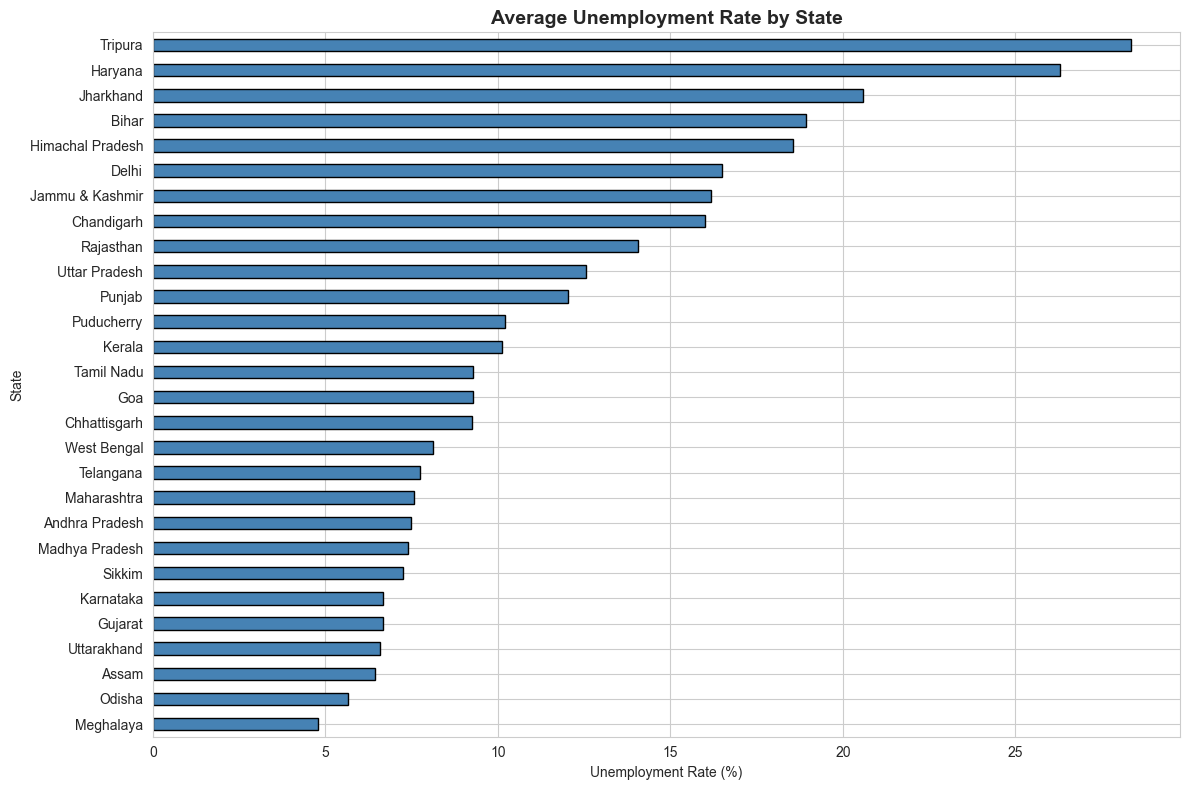

In [29]:
state_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
state_avg.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Unemployment Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../reports/figures/avg_unemployment_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Unemployment Rate Over Time

This line chart shows the overall unemployment trend. We can clearly see when the pandemic hit.

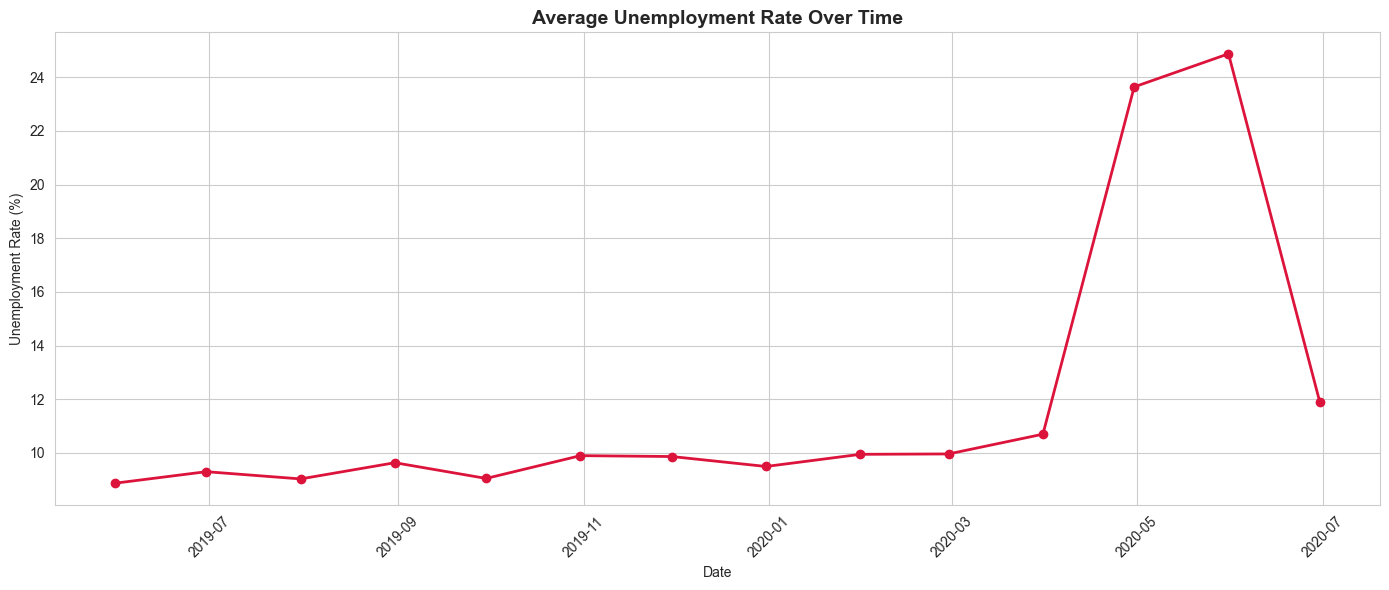

In [30]:
monthly_trend = df1.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', color='crimson', linewidth=2)
plt.title('Average Unemployment Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/unemployment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

The unemployment rate spiked sharply in April-May 2020, coinciding with the COVID-19 lockdown.

### Chart 3: Rural vs Urban Unemployment

Comparing the average unemployment between rural and urban areas.

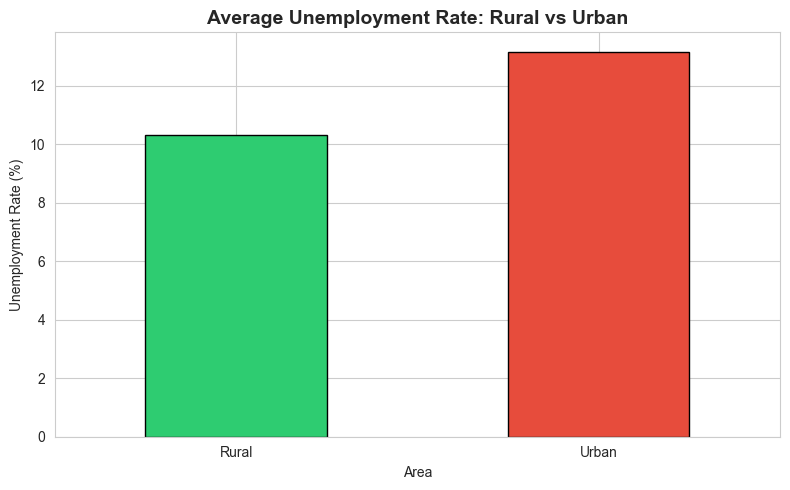

In [31]:
area_avg = df1.groupby('Area')['Unemployment_Rate'].mean()

plt.figure(figsize=(8, 5))
area_avg.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Average Unemployment Rate: Rural vs Urban', fontsize=14, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/rural_vs_urban.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Pre-COVID vs During COVID

A box plot comparing the spread of unemployment rates before and during the COVID-19 lockdown.

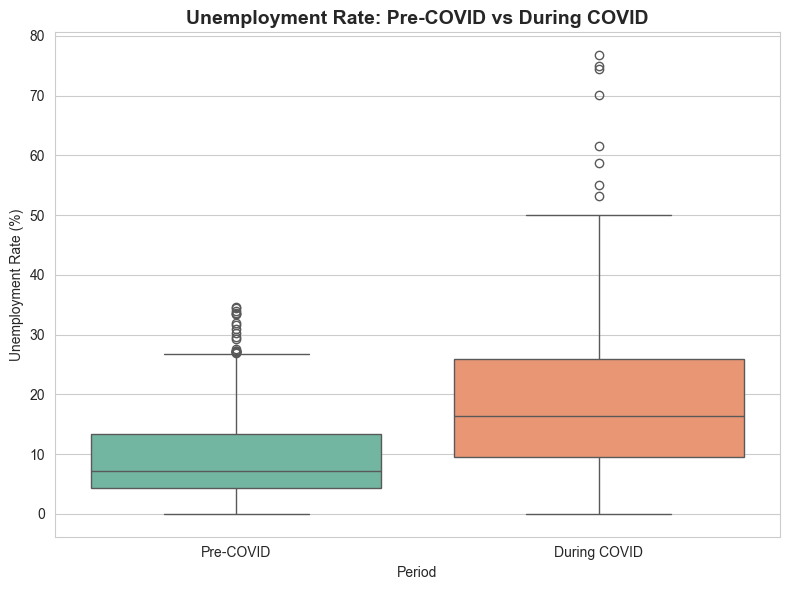

In [32]:
# Create a Period column based on the lockdown date
covid_start = pd.Timestamp('2020-04-01')
periods = []
for date in df1['Date']:
    if date >= covid_start:
        periods.append('During COVID')
    else:
        periods.append('Pre-COVID')
df1['Period'] = periods

plt.figure(figsize=(8, 6))
sns.boxplot(x='Period', y='Unemployment_Rate', data=df1, palette='Set2')
plt.title('Unemployment Rate: Pre-COVID vs During COVID', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../reports/figures/covid_impact_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Correlation Heatmap

This heatmap shows how strongly the numeric variables are related to each other.

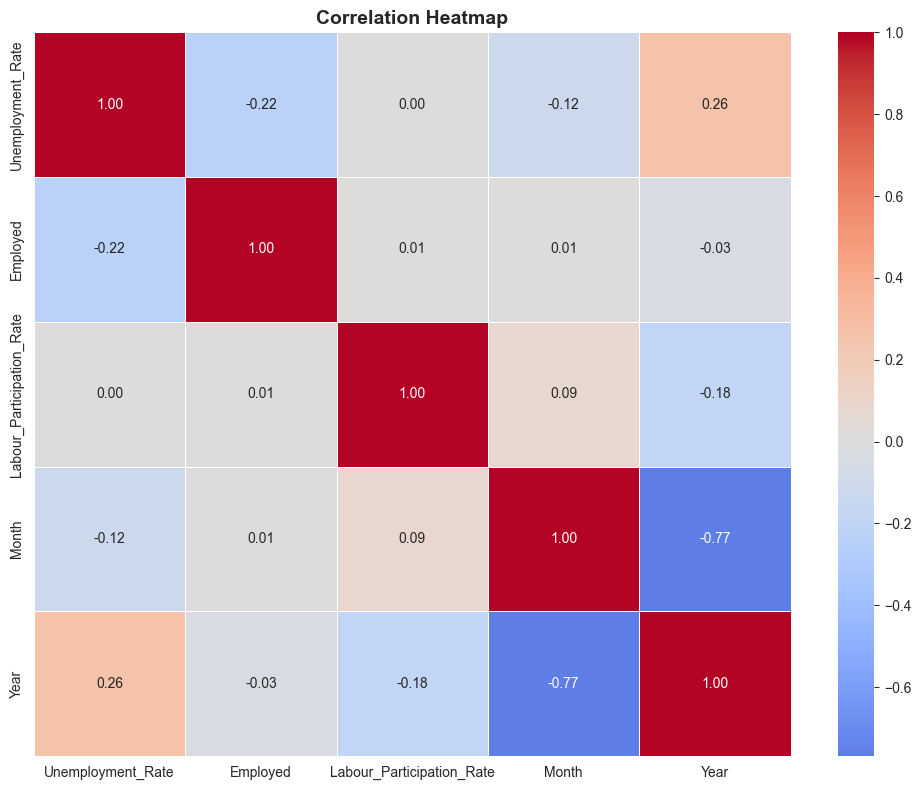

In [33]:
numeric_cols = df1.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Top 10 States with Highest Unemployment

Focusing on the 10 states that were most affected by unemployment during this period.

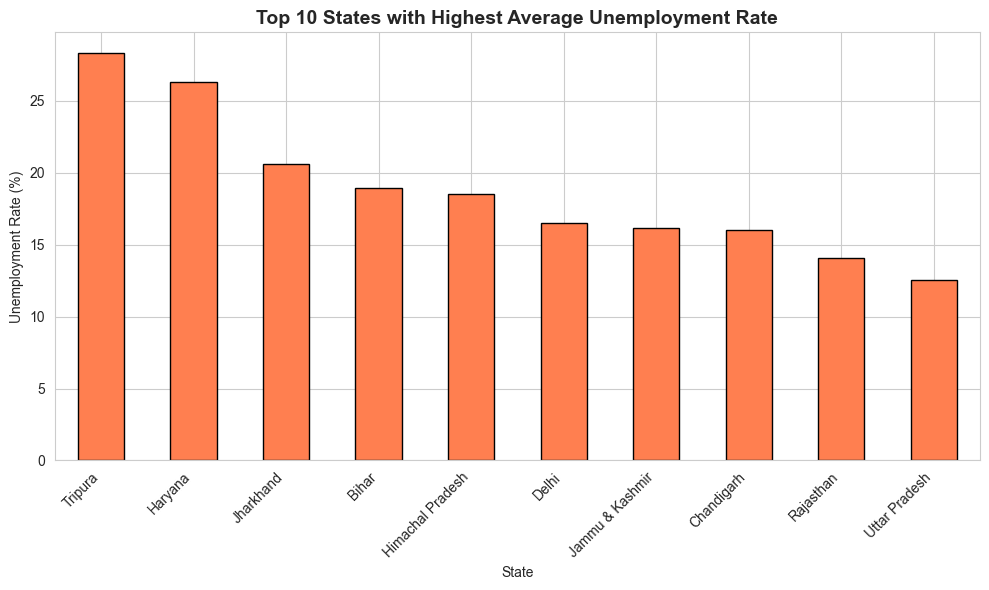

In [34]:
top10 = df1.groupby('Region')['Unemployment_Rate'].mean().nlargest(10)

plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 States with Highest Average Unemployment Rate', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/top10_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 7: Distribution of Unemployment Rate

A histogram with a KDE curve to see how unemployment rates are spread across all observations.

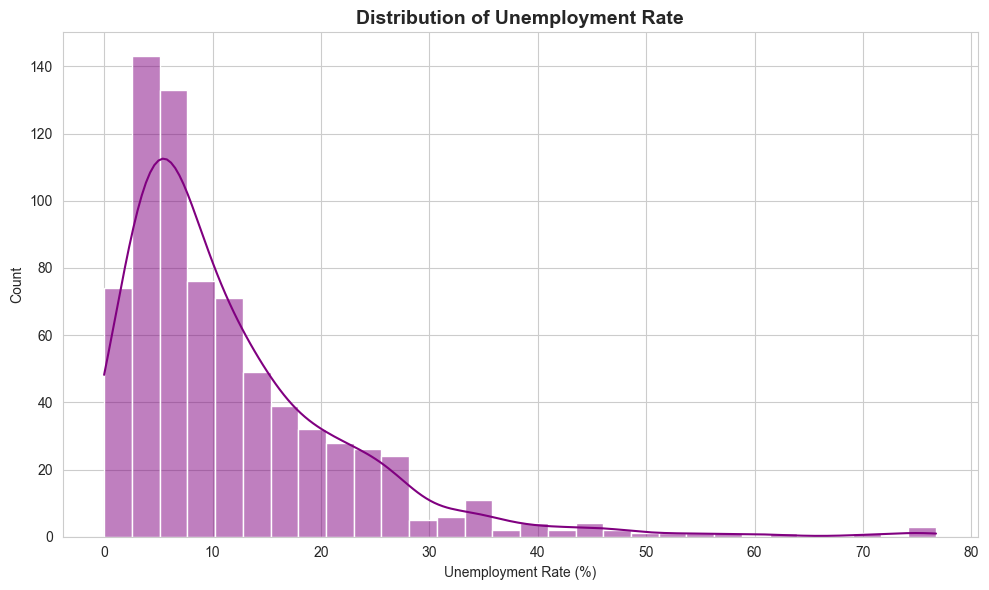

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['Unemployment_Rate'], bins=30, kde=True, color='purple')
plt.title('Distribution of Unemployment Rate', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/unemployment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The distribution is right-skewed, with most values below 20%. The long tail represents extreme unemployment during the lockdown period.

### Chart 8: Region-wise Average Unemployment

Using the second dataset to compare unemployment across broad geographic regions (North, South, East, West, etc.).

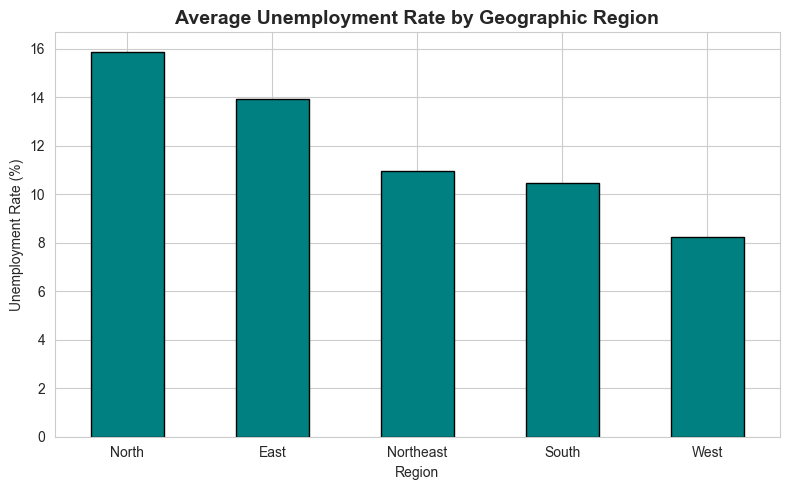

In [36]:
region_avg = df2.groupby('Geographic_Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_avg.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Unemployment Rate by Geographic Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/region_wise_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 9: Labour Participation vs Unemployment

A scatter plot to see if there's any relationship between how many people are looking for work and the unemployment rate.

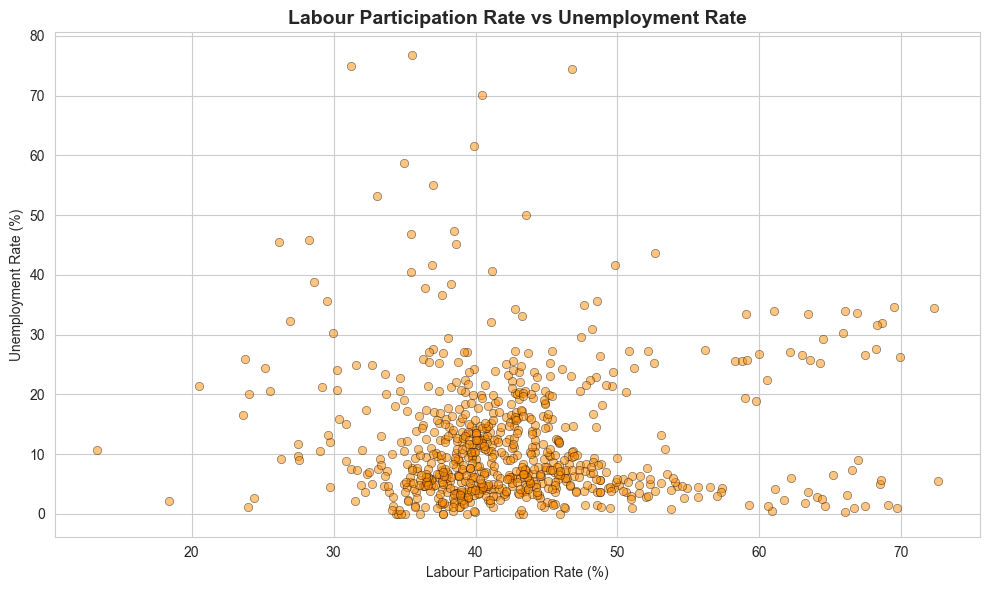

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df1['Labour_Participation_Rate'], df1['Unemployment_Rate'], alpha=0.5, color='darkorange', edgecolors='black', linewidth=0.5)
plt.title('Labour Participation Rate vs Unemployment Rate', fontsize=14, fontweight='bold')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../reports/figures/participation_vs_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 10: Monthly Average Unemployment

This shows which months typically have higher unemployment, averaging across all states and years.

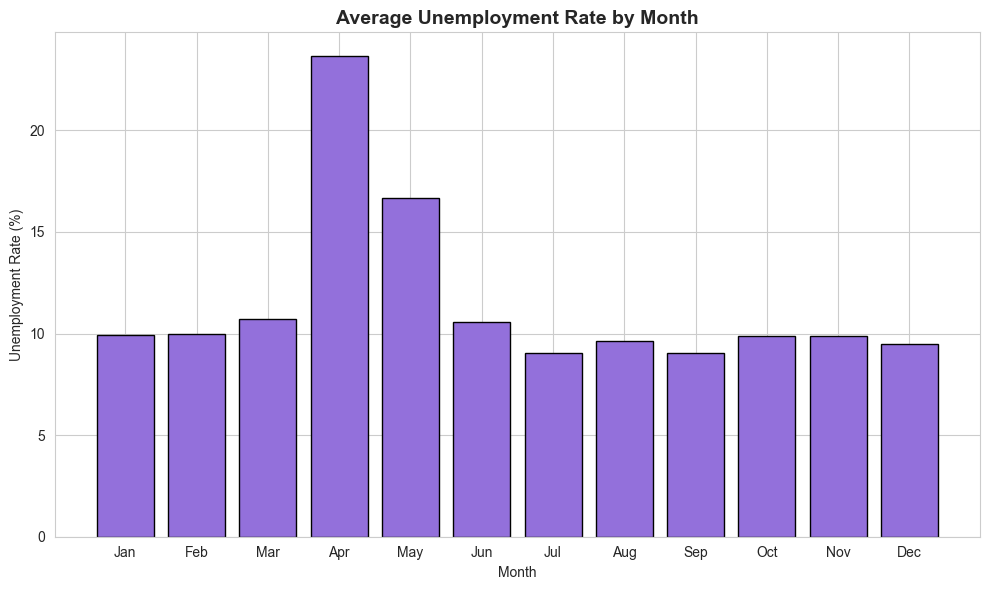

In [38]:
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_avg = df1.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10, 6))
plt.bar(range(len(monthly_avg)), monthly_avg.values, color='mediumpurple', edgecolor='black')
plt.xticks(range(len(monthly_avg)), [month_names.get(m, m) for m in monthly_avg.index])
plt.title('Average Unemployment Rate by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../reports/figures/monthly_avg_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 11: State-wise Employed Population

This horizontal bar chart shows the average number of employed people in each state.

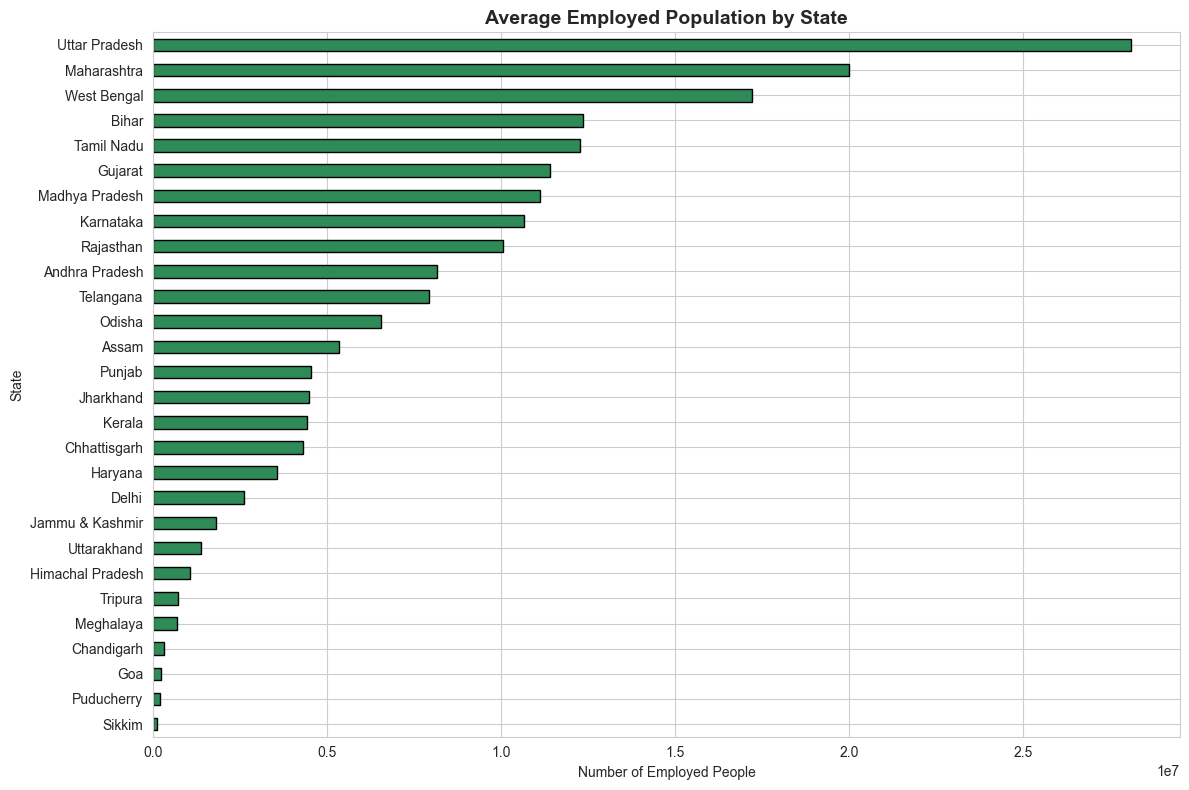

In [39]:
state_employed = df1.groupby('Region')['Employed'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
state_employed.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title('Average Employed Population by State', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employed People')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../reports/figures/employed_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering

We need to convert categorical columns into numbers so our ML models can understand them. We'll also create a flag for the COVID period.

In [40]:
# Create a copy for modeling
df_model = df1.copy()

# Encode categorical variables
le_region = LabelEncoder()
le_area = LabelEncoder()

df_model['Region_Encoded'] = le_region.fit_transform(df_model['Region'])
df_model['Area_Encoded'] = le_area.fit_transform(df_model['Area'])

# Create a COVID period flag
df_model['Is_COVID'] = (df_model['Date'] >= pd.Timestamp('2020-04-01')).astype(int)

print('Features created successfully')
print(df_model[['Region', 'Region_Encoded', 'Area', 'Area_Encoded', 'Is_COVID']].head(10))

Features created successfully
           Region  Region_Encoded   Area  Area_Encoded  Is_COVID
0  Andhra Pradesh               0  Rural             0         0
1  Andhra Pradesh               0  Rural             0         0
2  Andhra Pradesh               0  Rural             0         0
3  Andhra Pradesh               0  Rural             0         0
4  Andhra Pradesh               0  Rural             0         0
5  Andhra Pradesh               0  Rural             0         0
6  Andhra Pradesh               0  Rural             0         0
7  Andhra Pradesh               0  Rural             0         0
8  Andhra Pradesh               0  Rural             0         0
9  Andhra Pradesh               0  Rural             0         0


## Prepare Training Data

We'll select our features and target variable, then split the data into training and testing sets with an 80/20 split.

In [41]:
# Drop rows with any remaining NaN in the features or target
df_model = df_model.dropna(subset=['Region_Encoded', 'Area_Encoded', 'Month', 'Year', 'Labour_Participation_Rate', 'Is_COVID', 'Unemployment_Rate'])

# Select features and target
features = ['Region_Encoded', 'Area_Encoded', 'Month', 'Year', 'Labour_Participation_Rate', 'Is_COVID']
target = 'Unemployment_Rate'

X = df_model[features]
y = df_model[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

Training set size: 592
Testing set size: 148


## Train Machine Learning Models

We'll train three different regression models and compare their performance to find the best one.

### Model 1: Linear Regression

A simple linear model that assumes a straight-line relationship between features and the target.

In [42]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print('Linear Regression trained successfully')

Linear Regression trained successfully


### Model 2: Decision Tree Regressor

A tree-based model that splits the data into branches based on feature thresholds.

In [43]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print('Decision Tree trained successfully')

Decision Tree trained successfully


### Model 3: Random Forest Regressor

An ensemble of many decision trees that typically gives more stable and accurate predictions.

In [44]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print('Random Forest trained successfully')

Random Forest trained successfully


## Model Evaluation

Let's compare all three models using standard regression metrics: MAE, MSE, RMSE, and R² score.

In [45]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f'--- {name} ---')
    print(f'MAE:  {mae:.2f}')
    print(f'MSE:  {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R²:   {r2:.4f}')
    print()
    
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model('Linear Regression', y_test, lr_predictions))
results.append(evaluate_model('Decision Tree', y_test, dt_predictions))
results.append(evaluate_model('Random Forest', y_test, rf_predictions))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

--- Linear Regression ---
MAE:  6.82
MSE:  102.64
RMSE: 10.13
R²:   0.2911

--- Decision Tree ---
MAE:  5.23
MSE:  89.40
RMSE: 9.45
R²:   0.3825

--- Random Forest ---
MAE:  4.29
MSE:  60.86
RMSE: 7.80
R²:   0.5797

            Model      MAE        MSE      RMSE       R2
Linear Regression 6.819892 102.635540 10.130920 0.291082
    Decision Tree 5.232838  89.397005  9.454999 0.382522
    Random Forest 4.292999  60.855059  7.800965 0.579666


### Model Comparison Chart

Visualizing the R² scores side by side makes it easy to pick the best model.

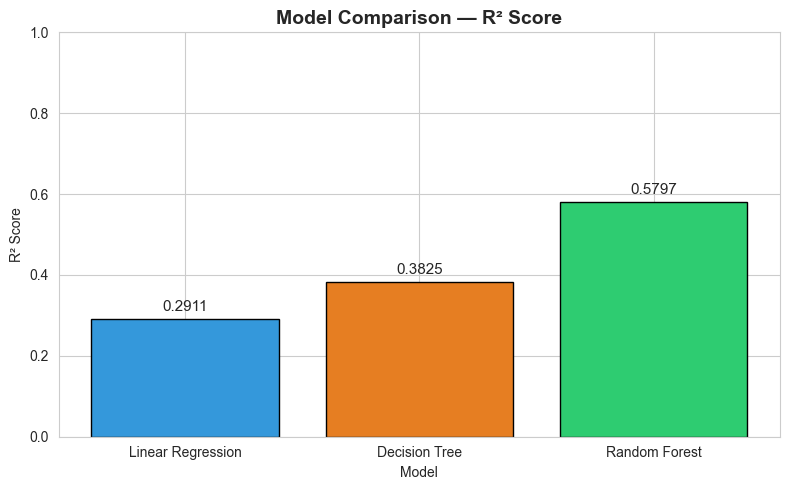

In [46]:
models = results_df['Model']
r2_scores = results_df['R2']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, r2_scores, color=['#3498db', '#e67e22', '#2ecc71'], edgecolor='black')
plt.title('Model Comparison — R² Score', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1)

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Actual vs Predicted (Random Forest)

Plotting predicted values against actual values — the closer the points are to the red dashed line, the better the model.

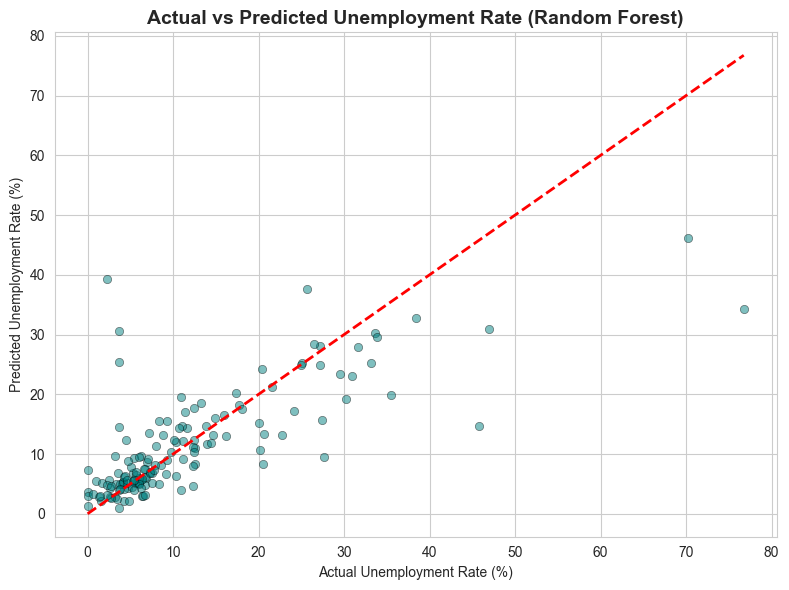

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5, color='teal', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Unemployment Rate (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Unemployment Rate (%)')
plt.ylabel('Predicted Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### Residual Plot

Residuals show the difference between actual and predicted values. Ideally, they should be randomly scattered around zero.

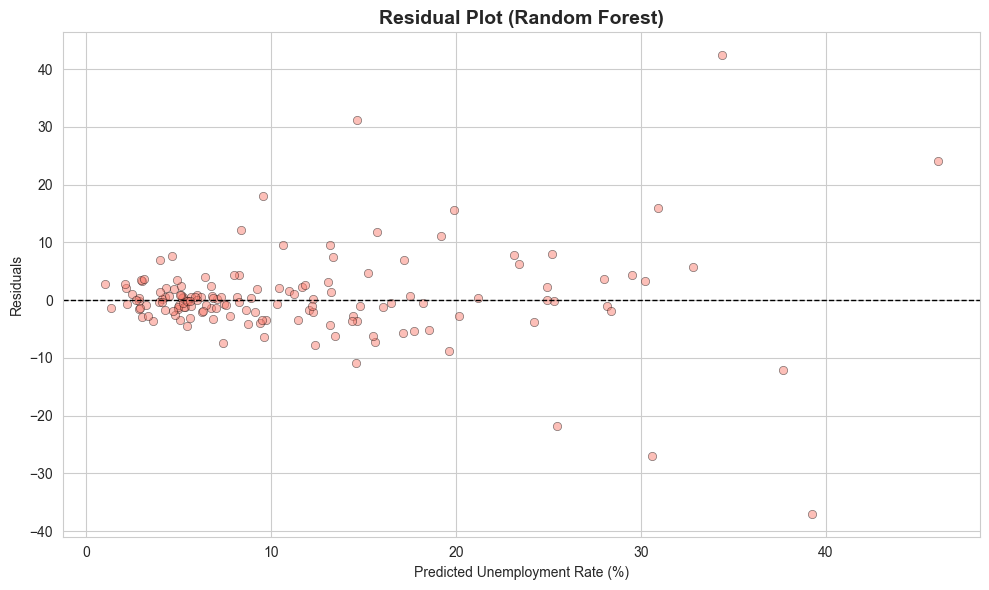

In [48]:
residuals = y_test - rf_predictions

plt.figure(figsize=(10, 6))
plt.scatter(rf_predictions, residuals, alpha=0.5, color='salmon', edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Unemployment Rate (%)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('../reports/figures/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

The residuals are mostly scattered around zero, which means our model is performing reasonably well. A few outliers exist for extreme unemployment cases during the lockdown.

## Predictions

Let's save the best model (Random Forest) so we can reuse it later, and look at some sample predictions.

In [49]:
# Save the best model
os.makedirs('../models', exist_ok=True)
with open('../models/random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
print('Model saved to ../models/random_forest_model.pkl')

Model saved to ../models/random_forest_model.pkl


In [50]:
# Show sample predictions
sample = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': rf_predictions[:10]
})
sample['Difference'] = abs(sample['Actual'] - sample['Predicted'])
print(sample.to_string(index=False))

 Actual  Predicted  Difference
  25.64    37.6835     12.0435
   6.29     9.6982      3.4082
   5.74     5.2345      0.5055
   6.78     5.9688      0.8112
   7.22    13.4630      6.2430
   6.20     5.6761      0.5239
   5.38     9.3715      3.9915
  31.61    27.9858      3.6242
   8.59     8.1372      0.4528
   5.56     5.1515      0.4085


## Key Insights

1. **COVID-19 had a massive impact on unemployment.** The average unemployment rate jumped from around 8% before April 2020 to over 20% during the lockdown months (April-May 2020). States like Bihar, Jharkhand, and Puducherry saw unemployment rates exceeding 40%.

2. **Urban areas were hit harder than rural areas.** Urban unemployment averaged higher than rural unemployment, likely because urban economies depend more on industries and services that were directly affected by lockdowns.

3. **The recovery was uneven across states.** Some states like Gujarat and Karnataka recovered quickly by June 2020, while states like Haryana and Tripura continued to struggle with high unemployment even after lockdowns eased.

4. **Labour participation rate has a weak negative correlation with unemployment.** When fewer people actively look for work (lower participation rate), the measured unemployment can appear lower — this suggests some workers simply dropped out of the labour force during the pandemic.

5. **Northern and Eastern regions faced higher unemployment** compared to Southern and Western India, indicating regional economic disparities in how the pandemic impact was absorbed.

6. **Random Forest was the best-performing model**, likely because the relationship between unemployment and its drivers is non-linear — the sudden COVID shock creates patterns that linear models cannot capture well.

## Conclusion

This project analyzed the unemployment situation in India from May 2019 to October 2020. The analysis clearly shows that the COVID-19 pandemic and the resulting nationwide lockdown caused an unprecedented spike in unemployment across all Indian states.

The exploratory data analysis revealed significant differences between rural and urban unemployment, regional variations, and the sharp but temporary nature of the unemployment shock. Using machine learning, we compared three regression models and found that the Random Forest Regressor performed the best in predicting unemployment rates based on geographic, temporal, and economic features.

The findings from this project could help policymakers understand which regions and demographics need the most support during economic crises, and help design targeted employment programs for future preparedness.